# OF Smoke Test (Config-Driven)

This notebook reads `of_smoke_config.json`, loads template/PSD, and runs:
- Short-trace checks (`fit`, `fit_with_shift`) against old baseline
- Raw vs filtered trace plots + similarity metrics
- Long-trace analysis using only new `sliding_fit`
- Explicit capture of the `chisq_mode='none'` error message

In [4]:
template, noise_psd, fs, template_src, noise_src = load_template_and_noise(cfg)
of_old, of_new = register_filters(template, noise_psd, fs)

print(f'fs: {fs}')
print(f'template source: {template_src}')
print(f'noise PSD source: {noise_src}')
print(f'template length: {template.size}')
print(f'noise PSD bins: {noise_psd.size}')

fs: 250000.0
template source: /home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/vac_ch_template.npy
noise PSD source: /home/dwong/DELight_mtr/trigger_study/archive/wk29/pink_psd.npy
template length: 32768
noise PSD bins: 16385


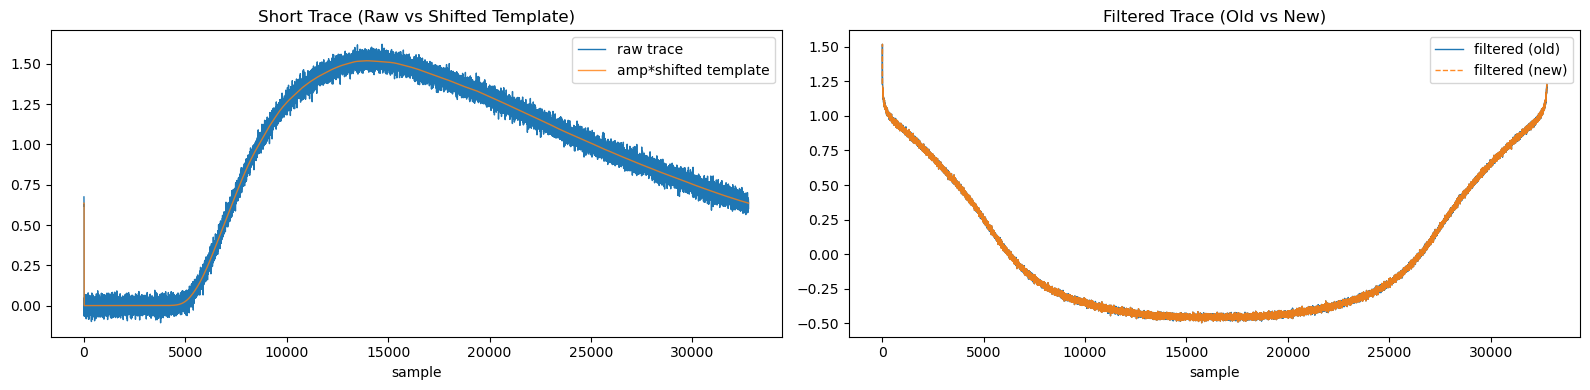

filtered old/new similarity: {'corr': 0.9999999999999999, 'rmse': 0.0, 'max_abs_diff': 0.0}
raw vs shifted-template similarity: {'corr': 0.9982660855285833, 'rmse': 0.030015581579127683, 'max_abs_diff': 0.1325284029783631}


In [5]:
# Short-trace example: plot raw and filtered traces, then check filtered old/new similarity.
rng = np.random.default_rng(int(cfg.get('seed', 123)))
amp_min, amp_max = cfg.get('short_amp_range', [0.5, 2.0])
shift_lo, shift_hi = cfg.get('allowed_shift_range', [-40, 40])
noise_std = float(cfg.get('short_trace_noise_std', 0.03))

amp_true = float(rng.uniform(amp_min, amp_max))
shift_true = int(rng.integers(shift_lo, shift_hi + 1))
trace_short = make_short_trace(template, amp_true, shift_true, noise_std, rng)
template_shifted = amp_true * np.roll(template, shift_true)

f_old = filtered_trace_td(of_old, trace_short)
f_new = filtered_trace_td(of_new, trace_short)

sim_filtered = similarity(f_old, f_new)
sim_raw_template = similarity(trace_short, template_shifted)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(trace_short, lw=1.0, label='raw trace')
axes[0].plot(template_shifted, lw=1.0, label='amp*shifted template', alpha=0.8)
axes[0].set_title('Short Trace (Raw vs Shifted Template)')
axes[0].set_xlabel('sample')
axes[0].legend(loc='upper right')

axes[1].plot(f_old, lw=1.0, label='filtered (old)')
axes[1].plot(f_new, lw=1.0, ls='--', label='filtered (new)', alpha=0.9)
axes[1].set_title('Filtered Trace (Old vs New)')
axes[1].set_xlabel('sample')
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

print('filtered old/new similarity:', sim_filtered)
print('raw vs shifted-template similarity:', sim_raw_template)

In [6]:
# Short traces with same length as template: check fit and fit_with_shift equivalence.
rng = np.random.default_rng(int(cfg.get('seed', 123)) + 1)
n_short = int(cfg.get('n_short_traces', 8))
amp_min, amp_max = cfg.get('short_amp_range', [0.5, 2.0])
shift_lo, shift_hi = cfg.get('allowed_shift_range', [-40, 40])
noise_std = float(cfg.get('short_trace_noise_std', 0.03))
atol = float(cfg.get('atol', 1e-9))
rtol = float(cfg.get('rtol', 1e-6))

fit_amp_d = []
fit_chi_d = []
shift_amp_d = []
shift_chi_d = []
shift_t0_d = []

allowed = (int(shift_lo), int(shift_hi))
for _ in range(n_short):
    amp = float(rng.uniform(amp_min, amp_max))
    shift = int(rng.integers(shift_lo, shift_hi + 1))
    tr = make_short_trace(template, amp, shift, noise_std, rng)

    ao, co = of_old.fit(tr)
    an, cn = of_new.fit(tr)
    fit_amp_d.append(abs(ao - an))
    fit_chi_d.append(abs(co - cn))

    aos, cos, t0o = of_old.fit_with_shift(tr, allowed_shift_range=allowed)
    ans, cns, t0n = of_new.fit_with_shift(tr, allowed_shift_range=allowed)
    shift_amp_d.append(abs(aos - ans))
    shift_chi_d.append(abs(cos - cns))
    shift_t0_d.append(abs(t0o - t0n))

print('fit max |amp_old-amp_new| =', np.max(fit_amp_d))
print('fit max |chi_old-chi_new| =', np.max(fit_chi_d))
print('fit_with_shift max |amp_old-amp_new| =', np.max(shift_amp_d))
print('fit_with_shift max |chi_old-chi_new| =', np.max(shift_chi_d))
print('fit_with_shift max |t0_old-t0_new| =', np.max(shift_t0_d))

assert np.allclose(fit_amp_d, 0.0, atol=atol, rtol=rtol)
assert np.allclose(fit_chi_d, 0.0, atol=atol, rtol=rtol)
assert np.allclose(shift_amp_d, 0.0, atol=atol, rtol=rtol)
assert np.allclose(shift_chi_d, 0.0, atol=atol, rtol=rtol)
assert np.max(shift_t0_d) == 0
print('PASS: short-trace fit and fit_with_shift match old baseline.')

fit max |amp_old-amp_new| = 1.1102230246251565e-16
fit max |chi_old-chi_new| = 4.0389678347315804e-28
fit_with_shift max |amp_old-amp_new| = 4.440892098500626e-16
fit_with_shift max |chi_old-chi_new| = 4.0389678347315804e-28
fit_with_shift max |t0_old-t0_new| = 0
PASS: short-trace fit and fit_with_shift match old baseline.


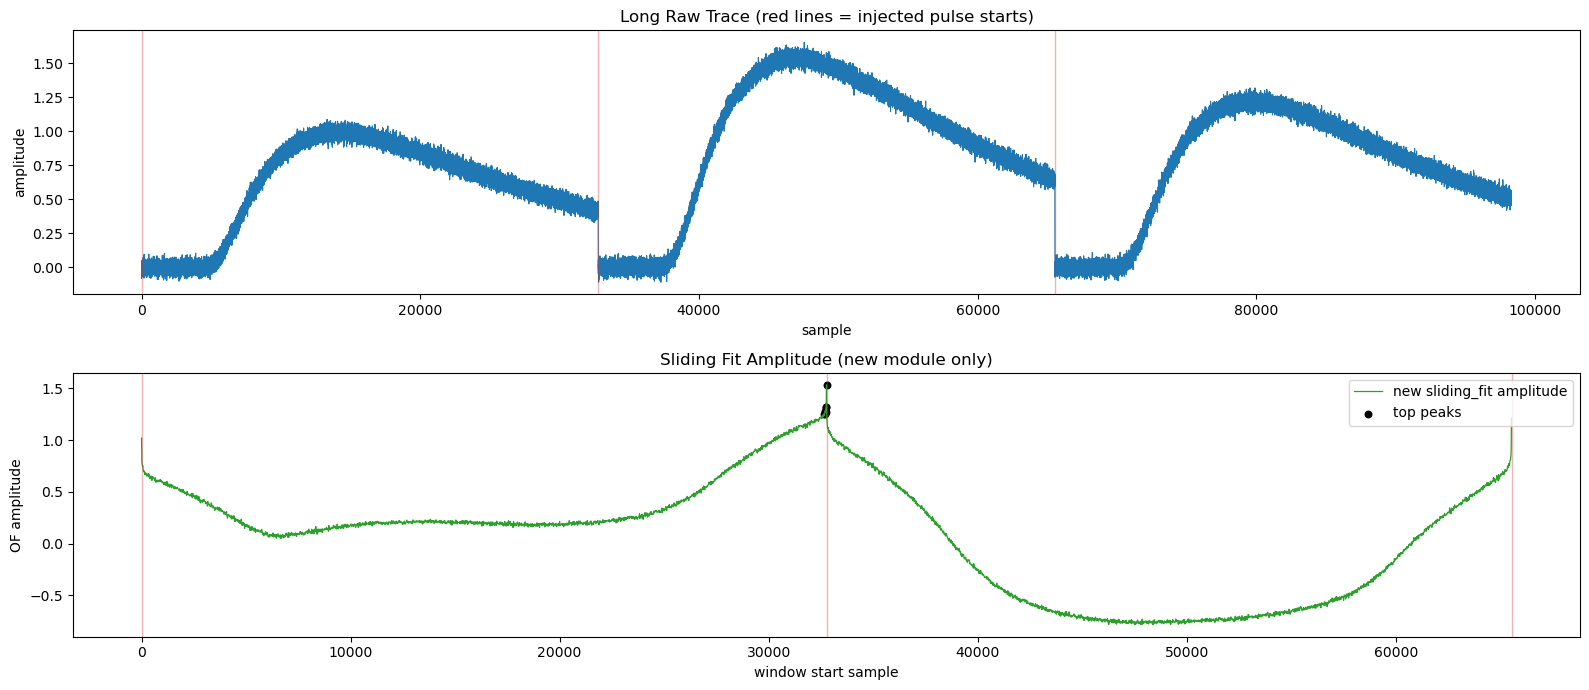

Injected starts: [0, 32768, 65536]
Top peak starts: [32768, 32752, 32736, 32704, 32720, 32688, 32672, 32640]


In [7]:
# Long trace: use NEW module sliding_fit (old module has no sliding_fit).
rng = np.random.default_rng(int(cfg.get('seed', 123)) + 2)
L = int(cfg.get('long_trace_len', template.size * 3))
if L <= template.size:
    raise ValueError('long_trace_len must be larger than template length.')

noise_std = float(cfg.get('long_trace_noise_std', 0.03))
n_inj = int(cfg.get('long_num_injections', 3))
a_lo, a_hi = cfg.get('long_amp_range', [0.6, 2.0])
hop = int(cfg.get('hop', 16))
reanchor_every = cfg.get('reanchor_every', 256)
reanchor_every = int(reanchor_every) if reanchor_every is not None else None

long_trace = rng.normal(0.0, noise_std, size=L)
max_start = L - template.size
starts = np.linspace(0, max_start, n_inj, dtype=int)
amps_true = rng.uniform(a_lo, a_hi, size=n_inj)
for s, a in zip(starts, amps_true):
    long_trace[s:s + template.size] += a * template

slide_amp, slide_chi = of_new.sliding_fit(long_trace, hop=hop, reanchor_every=reanchor_every, chisq_mode='all')
win_starts = np.arange(0, L - template.size + 1, hop, dtype=int)

topk = int(cfg.get('slide_peak_topk', 8))
peak_idx = np.argpartition(slide_amp, -topk)[-topk:]
peak_idx = peak_idx[np.argsort(slide_amp[peak_idx])[::-1]]
peak_starts = win_starts[peak_idx]

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)
axes[0].plot(long_trace, lw=0.8, color='tab:blue')
for s in starts:
    axes[0].axvline(s, color='tab:red', alpha=0.35, lw=1.0)
axes[0].set_title('Long Raw Trace (red lines = injected pulse starts)')
axes[0].set_xlabel('sample')
axes[0].set_ylabel('amplitude')

axes[1].plot(win_starts, slide_amp, lw=0.9, color='tab:green', label='new sliding_fit amplitude')
axes[1].scatter(peak_starts, slide_amp[peak_idx], color='black', s=22, label='top peaks')
for s in starts:
    axes[1].axvline(s, color='tab:red', alpha=0.35, lw=1.0)
axes[1].set_title('Sliding Fit Amplitude (new module only)')
axes[1].set_xlabel('window start sample')
axes[1].set_ylabel('OF amplitude')
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

print('Injected starts:', starts.tolist())
print('Top peak starts:', peak_starts.tolist())

In [8]:
# Read/capture the known error message for chisq_mode='none' on hop=1 path.
err_trace = long_trace[: template.size + 256].copy()
err_hop = 1

try:
    _amps_none, _chis_none = of_new.sliding_fit(
        err_trace, hop=err_hop, reanchor_every=256, chisq_mode='none'
    )
    print("sliding_fit(chisq_mode='none', hop=1) succeeded; no error observed in this run.")
except Exception as exc:
    print('Captured error type:', type(exc).__name__)
    print('Captured error message:', str(exc))
    print('Traceback tail:')
    print(''.join(traceback.format_exception(type(exc), exc, exc.__traceback__, limit=2)))


Captured error type: TypeError
Captured error message: not enough arguments: expected 13, got 12
Traceback tail:
Traceback (most recent call last):
  File "/tmp/ipykernel_3536612/1179341965.py", line 6, in <module>
    _amps_none, _chis_none = of_new.sliding_fit(
                             ^^^^^^^^^^^^^^^^^^^
  File "/home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/OptimumFilter.py", line 294, in sliding_fit
    _slide_block_hop1_amponly(
TypeError: not enough arguments: expected 13, got 12



## Notes

- Short traces are evaluated against old baseline for `fit` and `fit_with_shift`.
- Long traces use new `sliding_fit` only, as requested.
- Config values can be edited in `of_smoke_config.json` without touching notebook code.